In [1]:
import pandas as pd
import yfinance as yf


Downloading historical data starting from 2020
# This ensures we have enough samples (1,200+) for a "complex" project

In [2]:
stock = "NVDA"
df = yf.download(stock, start="2020-01-01")
print(df.head())

/tmp/ipykernel_21097/3584779920.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2020-01-02  5.970753  5.970753  5.891363  5.941884  237536000
2020-01-03  5.875188  5.918990  5.826159  5.851047  205384000
2020-01-06  5.899825  5.905051  5.755727  5.781859  262636000
2020-01-07  5.971251  6.017044  5.883149  5.928196  314856000
2020-01-08  5.982451  6.023765  5.926952  5.967021  277108000


Cleaning the MultiIndex (yfinance often returns double-headers)
# making  'Features' easy to calculate later

In [3]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Displaying the first few rows to verify the data

In [4]:
print(f"Successfully pulled {len(df)} rows of data for {stock}.")
print(df.head())

Successfully pulled 1586 rows of data for NVDA.
Price          Close      High       Low      Open     Volume
Date                                                         
2020-01-02  5.970753  5.970753  5.891363  5.941884  237536000
2020-01-03  5.875188  5.918990  5.826159  5.851047  205384000
2020-01-06  5.899825  5.905051  5.755727  5.781859  262636000
2020-01-07  5.971251  6.017044  5.883149  5.928196  314856000
2020-01-08  5.982451  6.023765  5.926952  5.967021  277108000


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Initialising Visualization (Position)

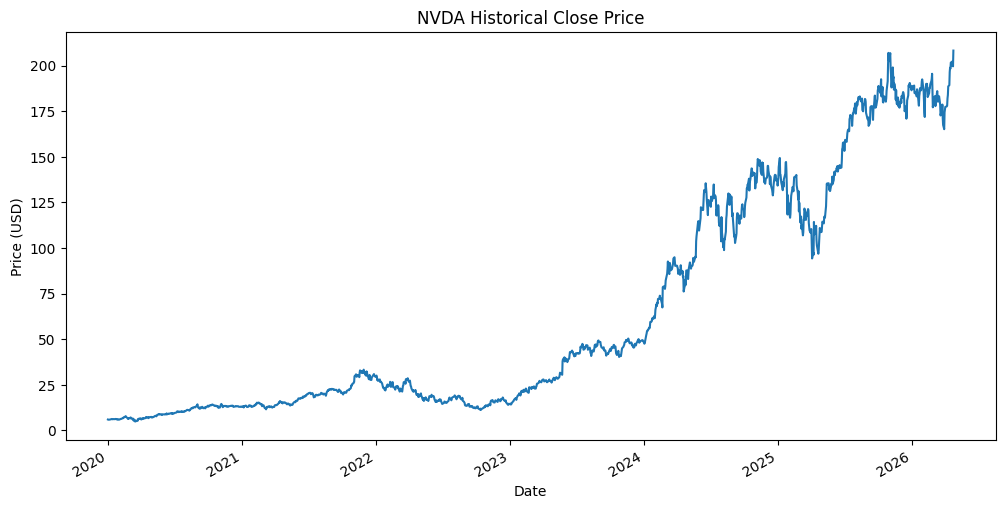

In [6]:
df['Close'].plot(figsize=(12, 6), title="NVDA Historical Close Price")
plt.ylabel("Price (USD)")
plt.show()

In this step, we transforming raw prices into "Signals" the model can actually understand.
 This is where our Calculus background shines, as we are essentially calculating the relative velocity and acceleration of the stock price.

Creating Moving Averages
# These smooth out the 'noise' to show the underlying trend (like an integral)

In [7]:
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

Engineering the Ratios (The 'Velocity' Features)
# This measures how far the price has 'stretched' from its average

In [8]:
df['Ratio10'] = df['Close'] / df['MA10']
df['Ratio50'] = df['Close'] / df['MA50']

Calculating Volatility (The 'Noise' Feature)
# This is the 10-day rolling standard deviation of daily percent changes

In [9]:
df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(window=10).std()

RSI (Relative Strength Index)

In [10]:
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(window=14).mean()
loss = -delta.clip(upper=0).rolling(window=14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / loss)))

 Creating the Target (The 'Answer Key')
# 1 if price goes UP tomorrow, 0 if it goes DOWN or stays flat
# We use .shift(-1) to look ahead one day

In [11]:
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

Cleaning Up
# Moving averages create 'NaN' values at the start; we must remove them

In [12]:
df = df.dropna()

In [13]:
print("Feature Engineering Complete!")
print(df[['Close', 'Ratio10', 'Ratio50', 'Volatility', 'RSI', 'Target']].head())

Feature Engineering Complete!
Price          Close   Ratio10   Ratio50  Volatility        RSI  Target
Date                                                                   
2020-03-13  5.997484  0.934829  0.936446    0.074086  42.267582       0
2020-03-16  4.890824  0.786774  0.766237    0.091197  36.464211       1
2020-03-17  5.410536  0.887668  0.848895    0.100658  40.237160       0
2020-03-18  5.050696  0.857242  0.794554    0.096994  40.306102       1
2020-03-19  5.303455  0.923691  0.836074    0.099998  38.554350       0


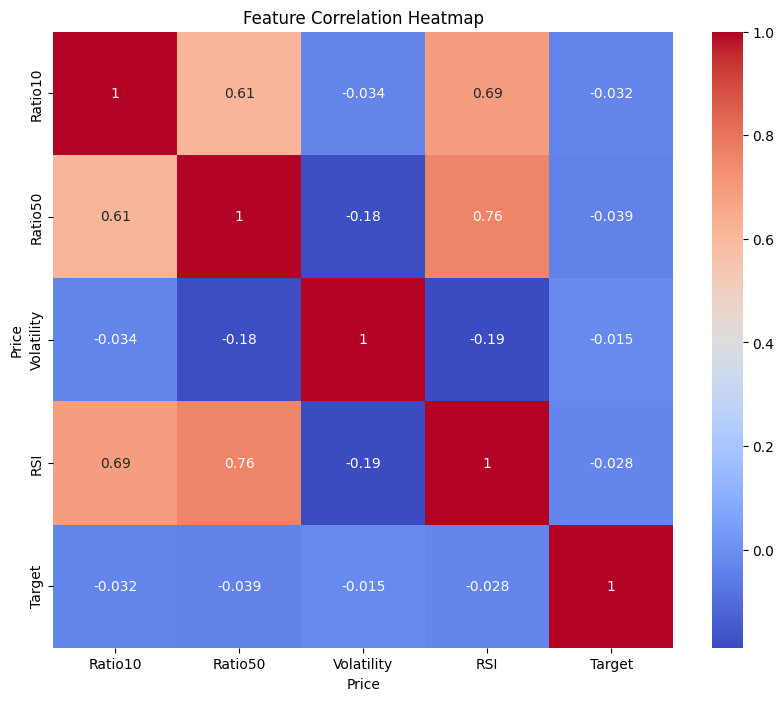

In [14]:
import seaborn as sns

# Create a correlation matrix
# This shows how much each 'Clue' relates to the 'Answer'
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Ratio10', 'Ratio50', 'Volatility', 'RSI', 'Target']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Using a Random Forest Classifier. This is a powerful "ensemble" algorithm that builds many decision trees and merges them together to get a more accurate and stable prediction.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Defining Features and Target

In [17]:
features = ['Ratio10', 'Ratio50', 'Volatility', 'RSI']
X = df[features]
y = df['Target']

Spliting the data (80% Train, 20% Test)
# Crucial: We do NOT shuffle because this is time-series data

In [18]:
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

Initializing the Model
# n_estimators=100 means we use 100 individual trees
# min_samples_split=50 helps prevent the model from 'memorizing' noise (overfitting)

In [19]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)

In [20]:
model.fit(X_train, y_train)


RandomForestClassifier(min_samples_split=50, random_state=1)

In [21]:
preds = model.predict(X_test)

Basic Evaluation

In [22]:
accuracy = accuracy_score(y_test, preds)
print(f"Model Accuracy on Test Set: {accuracy * 100:.2f}%")
f1 = f1_score(y_test, preds)
print(f"F1 Score on Test Set: {f1 * 100:.2f}%")
proba = model.predict_proba(X_test) [:, 1]
auc = roc_auc_score(y_test, proba)
print(f"AUC Score on Test Set: {auc:.3f}")

Model Accuracy on Test Set: 51.95%
F1 Score on Test Set: 62.05%
AUC Score on Test Set: 0.519


**Logistic Regression on this Data**

In [23]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

Basic Evaluation

In [25]:
lr_model_accuracy = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy on Test Set: {lr_model_accuracy * 100:.2f}%")
lr_model_f1 = f1_score(y_test, lr_preds)
print(f"F1 Score on Test Set: {lr_model_f1 * 100:.2f}%")
lr_model_auc = roc_auc_score(y_test, lr_proba)
print(f"AUC Score on Test Set: {lr_model_auc:.3f}")

Logistic Regression Accuracy on Test Set: 54.55%
F1 Score on Test Set: 70.59%
AUC Score on Test Set: 0.512


**Ablation Study**

Testing how feature performance for full model

In [42]:
import pandas as pd
ab_results = []
full_feat = ['Ratio10', 'Ratio50', 'Volatility', 'RSI']
model_full = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)
model_full.fit(df[full_feat].iloc[:split], y_train)
preds_full = model_full.predict(df[full_feat].iloc[split:])
proba_full = model_full.predict_proba(df[full_feat].iloc[split:])[:, 1]
ab_results.append({'Variant': 'Full Model', 'Config':'All features','Accuracy': round(accuracy_score(y_test, preds_full)*100, 1), 'F1': round(f1_score(y_test, preds_full)*100, 1), 'AUC': round(roc_auc_score(y_test, proba_full),3)})

Testing how feature perform without Ration_10

In [43]:
full_feat = ['Ratio50', 'Volatility', 'RSI']
model_full = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)
model_full.fit(df[full_feat].iloc[:split], y_train)
preds_full = model_full.predict(df[full_feat].iloc[split:])
proba_full = model_full.predict_proba(df[full_feat].iloc[split:])[:, 1]
ab_results.append({'Variant': 'without Ratio10', 'Config':'Removed shortterm','Accuracy': round(accuracy_score(y_test, preds_full)*100, 1), 'F1': round(f1_score(y_test, preds_full)*100, 1), 'AUC': round(roc_auc_score(y_test, proba_full),3)})


Testing how feature perform without Ration_50

In [44]:
full_feat = ['Ratio10', 'Volatility', 'RSI']
model_full = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)
model_full.fit(df[full_feat].iloc[:split], y_train)
preds_full = model_full.predict(df[full_feat].iloc[split:])
proba_full = model_full.predict_proba(df[full_feat].iloc[split:])[:, 1]
ab_results.append({'Variant': 'without Ratio50', 'Config':'Removed Longterm','Accuracy': round(accuracy_score(y_test, preds_full)*100, 1), 'F1': round(f1_score(y_test, preds_full)*100, 1), 'AUC': round(roc_auc_score(y_test, proba_full),3)})

Testing how feature perform without Volatility

In [45]:
full_feat = ['Ratio10', 'Ratio50', 'RSI']
model_full = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)
model_full.fit(df[full_feat].iloc[:split], y_train)
preds_full = model_full.predict(df[full_feat].iloc[split:])
proba_full = model_full.predict_proba(df[full_feat].iloc[split:])[:, 1]
ab_results.append({'Variant': 'without Volatility', 'Config':'Removed market noise','Accuracy': round(accuracy_score(y_test, preds_full)*100, 1), 'F1': round(f1_score(y_test, preds_full)*100, 1), 'AUC': round(roc_auc_score(y_test, proba_full),3)})

Without RSI

In [46]:
full_feat = ['Ratio10', 'Ratio50', 'Volatility']
model_full = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)
model_full.fit(df[full_feat].iloc[:split], y_train)
preds_full = model_full.predict(df[full_feat].iloc[split:])
proba_full = model_full.predict_proba(df[full_feat].iloc[split:])[:, 1]
ab_results.append({'Variant': 'without RSI', 'Config':'Removed momentum','Accuracy': round(accuracy_score(y_test, preds_full)*100, 1), 'F1': round(f1_score(y_test, preds_full)*100, 1), 'AUC': round(roc_auc_score(y_test, proba_full),3)})

Reduced Tree

In [47]:
full_feat = ['Ratio10', 'Ratio50', 'Volatility', 'RSI']
model_full = RandomForestClassifier(n_estimators=50, min_samples_split=50, random_state=1)
model_full.fit(df[full_feat].iloc[:split], y_train)
preds_full = model_full.predict(df[full_feat].iloc[split:])
proba_full = model_full.predict_proba(df[full_feat].iloc[split:])[:, 1]
ab_results.append({'Variant': 'Tree Reduced', 'Config':'Reduced to 50','Accuracy': round(accuracy_score(y_test, preds_full)*100, 1), 'F1': round(f1_score(y_test, preds_full)*100, 1), 'AUC': round(roc_auc_score(y_test, proba_full),3)})

In [48]:
ab_df = pd.DataFrame(ab_results)
print(ab_df)

              Variant                Config  Accuracy    F1    AUC
0          Full Model          All features      51.9  62.1  0.519
1     without Ratio10     Removed shortterm      51.6  60.7  0.519
2     without Ratio50      Removed Longterm      51.3  60.5  0.520
3  without Volatility  Removed market noise      54.5  65.9  0.517
4         without RSI      Removed momentum      51.6  61.5  0.521
5        Tree Reduced         Reduced to 50      51.3  60.5  0.509


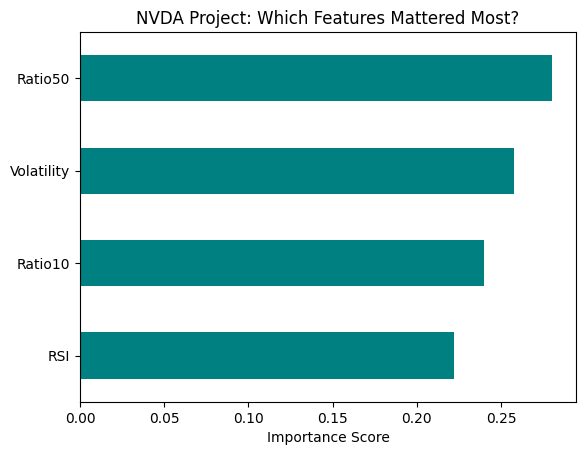

In [50]:
import matplotlib.pyplot as plt

# Get the importance of each feature
importances = pd.Series(model.feature_importances_, index=features)

# Plotting
importances.sort_values().plot(kind='barh', color='teal')
plt.title("NVDA Project: Which Features Mattered Most?")
plt.xlabel("Importance Score")
plt.show()

#  Preparing the results dataframe from your test set

In [51]:
test_results = X_test.copy()
test_results['Actual_Returns'] = test.loc[X_test.index, 'Returns']
test_results['Predicted_Signal'] = preds

Calculating Strategy Returns
# Strategy Return = Predicted Signal * Actual Returns
# If signal is 1, you gain/lose the market return. If 0, your return is 0 (cash).

In [52]:
test_results['Strategy_Returns'] = test_results['Predicted_Signal'] * test_results['Actual_Returns']

# 3. Calculating Cumulative Performance (The Growth of $1)

In [53]:
test_results['Market_Growth'] = (1 + test_results['Actual_Returns']).cumprod()
test_results['Strategy_Growth'] = (1 + test_results['Strategy_Returns']).cumprod()

In [54]:
print("Backtesting calculations complete!")
print(test_results[['Actual_Returns', 'Strategy_Returns', 'Market_Growth', 'Strategy_Growth']].tail())

Backtesting calculations complete!
Price       Actual_Returns  Strategy_Returns  Market_Growth  Strategy_Growth
Date                                                                        
2026-04-20        0.001884          0.001884       1.683403         1.413631
2026-04-21       -0.010789         -0.010789       1.665241         1.398379
2026-04-22        0.013108          0.013108       1.687069         1.416709
2026-04-23       -0.014123         -0.014123       1.663242         1.396700
2026-04-24        0.043228          0.043228       1.735140         1.457077


high-quality chart in your final report, running this visualization. It comparing  "AI-driven" strategy against simply "Buying and Holding" NVDA.

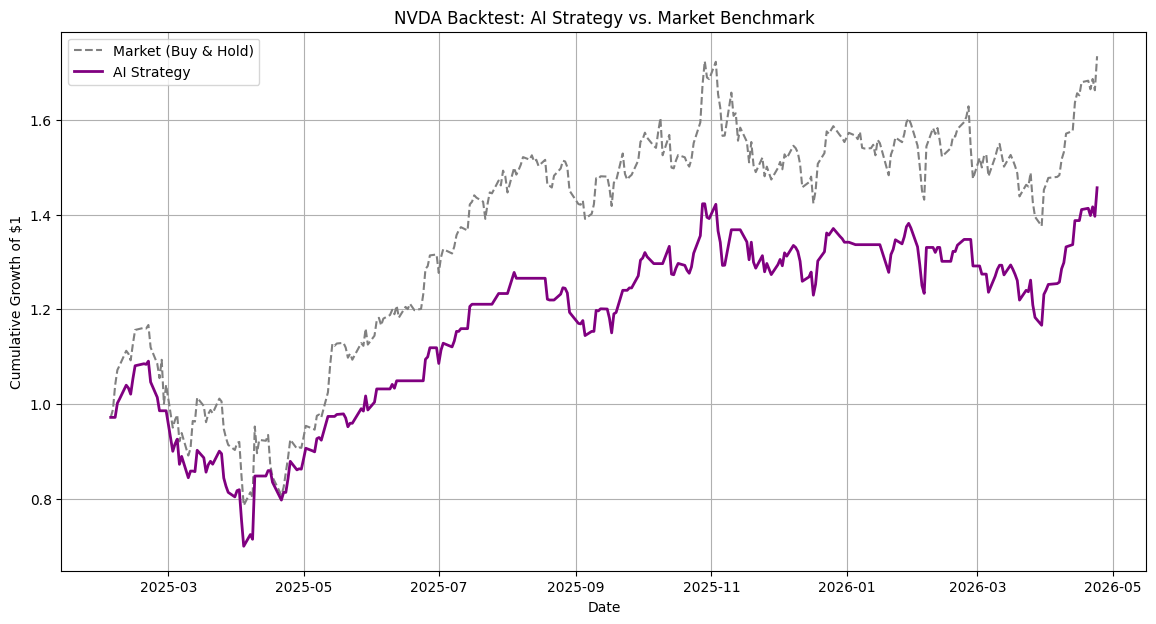

In [55]:
plt.figure(figsize=(14, 7))
plt.plot(test_results['Market_Growth'], label='Market (Buy & Hold)', color='gray', linestyle='--')
plt.plot(test_results['Strategy_Growth'], label='AI Strategy', color='purple', linewidth=2)
plt.title("NVDA Backtest: AI Strategy vs. Market Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

 **Predicted vs. Actual Direction**

> Add blockquote



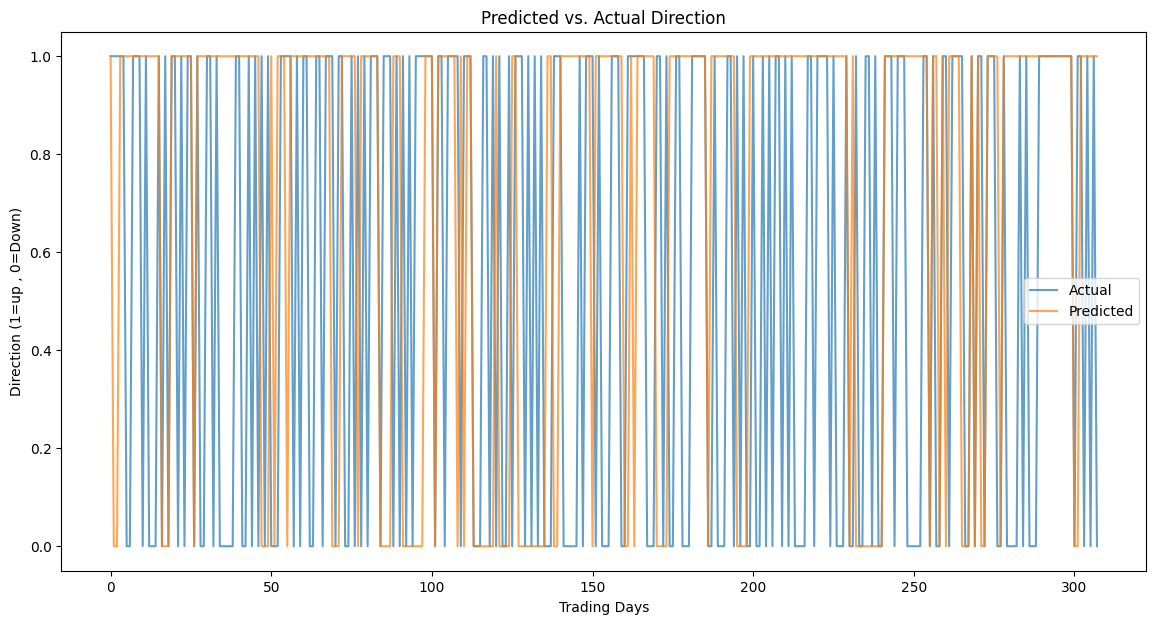

In [58]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.values, label='Actual', alpha = 0.7)
plt.plot(preds, label='Predicted', alpha = 0.7)
plt.title("Predicted vs. Actual Direction")
plt.xlabel("Trading Days")
plt.ylabel("Direction (1=up , 0=Down)")
plt.legend()
plt.show()

Predicted vs. Actual Direction for first 100 days.

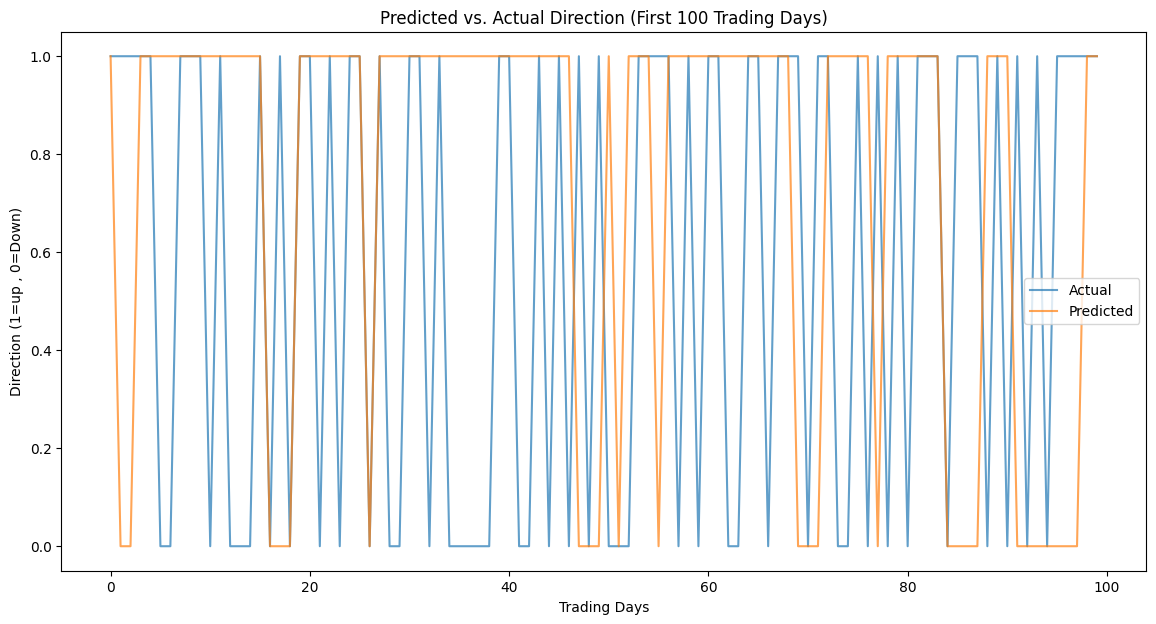

In [59]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.values[:100], label='Actual', alpha = 0.7)
plt.plot(preds[:100], label='Predicted', alpha = 0.7)
plt.title("Predicted vs. Actual Direction (First 100 Trading Days)")
plt.xlabel("Trading Days")
plt.ylabel("Direction (1=up , 0=Down)")
plt.legend()
plt.show()